## 6.获得所有预测结果

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import seaborn as sns

In [2]:
# 定义区间
train_begin_date = pd.to_datetime("2024-06-01")
train_end_date = pd.to_datetime("2025-05-30")
test_begin_date = pd.to_datetime("2025-06-01")
test_end_date = pd.to_datetime("2025-06-30")

In [12]:
# 生成随机结构化数据

# 创建一个函数来生成随机数据
def generate_random_data(start_date, end_date, seed=42):
    np.random.seed(seed)
    
    # 计算日期范围
    date_range = pd.date_range(start=start_date, end=end_date)
    
    data = []
    
    # 为每一天的每个小时生成数据
    for date in date_range:
        for hour in range(24):
            # 生成真实值 - 考虑时间模式
            base_price = 200 + 200 * np.sin(hour / 24 * 2 * np.pi)  # 日内波动
            random_factor = np.random.normal(0, 50)  # 随机波动
            
            true_price = max(0, base_price + random_factor)
            
            # 生成预测值 - 添加一些预测误差
            prediction_error = np.random.normal(0, true_price * 0.3)  # 15%的误差范围
            predicted_price = max(0, true_price + prediction_error)
            
            data.append({
                'date': date,
                'hour': hour,
                'true': true_price,
                'origin_pred': predicted_price
            })
    
    return pd.DataFrame(data)

# 使用定义的日期范围生成随机数据
all_result = generate_random_data(train_begin_date, test_end_date)
all_result

,date,hour,true,origin_pred
0,2024-06-01,0,224.835708,215.509682
1,2024-06-01,1,284.148236,413.978110
2,2024-06-01,2,288.292331,268.042365
3,2024-06-01,3,420.381997,517.166720
4,2024-06-01,4,349.731361,406.656440
...,...,...,...,...
9475,2025-06-30,19,0.000000,0.000000
9476,2025-06-30,20,0.000000,0.000000
9477,2025-06-30,21,53.741173,46.834008
9478,2025-06-30,22,113.070225,99.009393


# ⬆️ 只要将 all_result 做成上面这种结构, 就能执行以下的指标计算与可视化

```
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         9480 non-null   datetime64[ns]
 1   hour         9480 non-null   int64         
 2   true         9480 non-null   float64       
 3   origin_pred  9480 non-null   float64
```       

In [4]:
# 计算准确率与达标率
# 计算每个预测点是否达标
all_result['pred'] = 0  # 默认设置为不达标
all_result['meets_standard'] = False  # 默认设置为不达标

# 遍历每一行数据
for i, row in all_result.iterrows():
    true_val = row['true']
    pred_val = row['origin_pred']

    # 根据不同情况判断是否达标
    if true_val >= 80:
        # 高电价区间：误差百分比小于 20% 为达标
        error_pct = abs(true_val - pred_val) / true_val * 100
        meets_standard = error_pct < 20
        all_result.loc[i, 'error_pct'] = error_pct
    else:
        # 低电价区间：预测值小于 80 为达标
        meets_standard = pred_val < 80
        all_result.loc[i, 'error_pct'] = np.nan
    
    all_result.loc[i, 'pred'] = pred_val
    all_result.loc[i, 'meets_standard'] = meets_standard

all_result

,date,hour,true,origin_pred,pred,meets_standard,error_pct
0,2024-06-01,0,224.835708,215.509682,215.509682,True,4.147929
1,2024-06-01,1,284.148236,413.978110,413.978110,False,45.690896
2,2024-06-01,2,288.292331,268.042365,268.042365,True,7.024109
3,2024-06-01,3,420.381997,517.166720,517.166720,False,23.023042
4,2024-06-01,4,349.731361,406.656440,406.656440,True,16.276801
...,...,...,...,...,...,...,...
9475,2025-06-30,19,0.000000,0.000000,0.000000,True,NaN
9476,2025-06-30,20,0.000000,0.000000,0.000000,True,NaN
9477,2025-06-30,21,53.741173,46.834008,46.834008,True,NaN
9478,2025-06-30,22,113.070225,99.009393,99.009393,True,12.435487


In [5]:
# 显示 test_result DataFrame 的内容
print("test_result DataFrame 的基本信息：")
print(f"形状: {all_result.shape}")
print(f"列名: {all_result.columns.tolist()}")
# print("\n字段类型：")
# print(test_result.dtypes)
# print("\n前 5 行数据：")
# print(test_result.head(5))

# 计算高电价区间的预测准确率
high_price_mask = all_result['true'] >= 80
high_price_accuracy = all_result.loc[high_price_mask, 'meets_standard'].mean() * 100 if high_price_mask.sum() > 0 else 0

# 计算低电价区间的预测准确率
low_price_mask = all_result['true'] < 80
low_price_accuracy = all_result.loc[low_price_mask, 'meets_standard'].mean() * 100 if low_price_mask.sum() > 0 else 0

# 计算总体准确率
overall_accuracy = all_result['meets_standard'].mean() * 100

print(f"\n总体预测准确率: {overall_accuracy:.2f}%")
print(f"高电价区间(≥80)准确率: {high_price_accuracy:.2f}%")
print(f"低电价区间(<80)准确率: {low_price_accuracy:.2f}%")

test_result = all_result[(all_result['date'] >= test_begin_date) & (all_result['date'] <= test_end_date)]

# 计算 test_result 的预测准确率
print("\ntest_result DataFrame 的基本信息：")
print(f"形状: {test_result.shape}")
print(f"列名: {test_result.columns.tolist()}")

# 计算高电价区间的预测准确率
high_price_mask = test_result['true'] >= 80
high_price_accuracy = test_result.loc[high_price_mask, 'meets_standard'].mean() * 100 if high_price_mask.sum() > 0 else 0

# 计算低电价区间的预测准确率  
low_price_mask = test_result['true'] < 80
low_price_accuracy = test_result.loc[low_price_mask, 'meets_standard'].mean() * 100 if low_price_mask.sum() > 0 else 0

# 计算总体准确率
overall_accuracy = test_result['meets_standard'].mean() * 100

print(f"\n测试集总体预测准确率: {overall_accuracy:.2f}%")
print(f"测试集高电价区间(≥80)准确率: {high_price_accuracy:.2f}%") 
print(f"测试集低电价区间(<80)准确率: {low_price_accuracy:.2f}%")

test_result DataFrame 的基本信息：
形状: (9480, 7)
列名: ['date', 'hour', 'true', 'origin_pred', 'pred', 'meets_standard', 'error_pct']

总体预测准确率: 62.11%
高电价区间(≥80)准确率: 50.15%
低电价区间(<80)准确率: 93.57%

test_result DataFrame 的基本信息：
形状: (720, 7)
列名: ['date', 'hour', 'true', 'origin_pred', 'pred', 'meets_standard', 'error_pct']

测试集总体预测准确率: 62.50%
测试集高电价区间(≥80)准确率: 50.29%
测试集低电价区间(<80)准确率: 93.60%


## 7.单天可视化

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analyze_and_visualize_day_predictions(test_result, target_date_str="2025-04-18"):
    """
    对单日电力价格预测结果进行分析和可视化，包括统计达标率、绘制预测结果和误差分析图、以及绘制真实值vs预测值的散点图。

    Args:
        test_result (pd.DataFrame): 包含日期、小时、真实值、预测值、是否达标和误差百分比的DataFrame。
        target_date_str (str):  需要分析的目标日期，格式为"YYYY-MM-DD"。 默认为"2025-06-18"。

    Returns:
        None.  该函数会打印统计结果并显示图表。
    """
    target_date = pd.to_datetime(target_date_str)
    test_df = test_result[test_result['date'] == target_date].copy()

    # 确保提取到了数据，如果没有，则创建空的 DataFrame
    if test_df.empty:
        test_df = pd.DataFrame(columns=['date', 'hour', 'true', 'pred', 'meets_standard', 'error_pct'])

    # 重命名列以匹配后续代码的期望
    test_df.rename(columns={'true': 'true_value', 'pred': 'predicted_value'}, inplace=True)

    # 统计达标率
    if not test_df.empty:
        high_price_std_met = test_df[test_df['true_value'] >= 80]['meets_standard'].mean() * 100
        low_price_std_met = test_df[test_df['true_value'] < 80]['meets_standard'].mean() * 100
        overall_std_met = test_df['meets_standard'].mean() * 100
    else:
        high_price_std_met = np.nan
        low_price_std_met = np.nan
        overall_std_met = np.nan

    # 打印统计结果
    print(f"\n=== {target_date.date()} Prediction Results Statistics (New Evaluation Standard) ===")
    print(f"Overall Standard Met Rate: {overall_std_met:.2f}%")
    print(f"High Price (≥80) Standard Met Rate: {high_price_std_met:.2f}%")
    print(f"Low Price (<80) Standard Met Rate: {low_price_std_met:.2f}%")

    # 添加价格类别列
    test_df['price_category'] = test_df['true_value'].apply(lambda x: 'High (≥80)' if x >= 80 else 'Low (<80)')
    test_df['pred_category'] = test_df['predicted_value'].apply(lambda x: 'High (≥80)' if x >= 80 else 'Low (<80)')

    # 混淆矩阵
    confusion = pd.crosstab(
        test_df['price_category'],
        test_df['pred_category'],
        normalize='index'
    ) * 100
    print("\nPrice Category Prediction Confusion Matrix (%):")
    print(confusion)

    # 可视化预测结果 - 合并价格预测和误差分析到一张图
    fig, ax1 = plt.subplots(figsize=(20, 9))  # Increased figure size

    # 绘制价格预测线
    line1, = ax1.plot(test_df['hour'], test_df['true_value'], marker='o', label='True Price', color='blue', linewidth=8, markersize=12)  # Increased linewidth and markersize
    line2, = ax1.plot(test_df['hour'], test_df['predicted_value'], marker='x', label='Predicted Price', color='orange', linewidth=8, markersize=12)  # Increased linewidth and markersize

    # 添加80元/MWh阈值线
    threshold_line = ax1.axhline(y=80, color='gray', linestyle='--', alpha=0.7, label='80 CNY/MWh Threshold', linewidth=4)  # Increased linewidth

    # 标记预测达标与未达标的点
    for i, row in test_df.iterrows():
        if not np.isnan(row['true_value']):
            if row['meets_standard']:
                ax1.plot(row['hour'], row['true_value'], 'go', markersize=30, alpha=0.5)  # 绿色圈表示达标, Increased markersize and alpha
            else:
                ax1.plot(row['hour'], row['true_value'], 'ro', markersize=30, alpha=0.5)  # 红色圈表示未达标, Increased markersize and alpha

    # 设置左侧y轴标签
    ax1.set_xlabel('Hour', fontsize=16)  # Increased fontsize
    ax1.set_ylabel('Price (CNY/MWh)', color='blue', fontsize=16)  # Increased fontsize
    ax1.tick_params(axis='y', labelcolor='blue', labelsize=14)  # Increased fontsize
    ax1.tick_params(axis='x', labelsize=14)
    ax1.set_xticks(range(24))
    ax1.grid(True, alpha=0.3)

    # 创建右侧y轴用于误差分析
    ax2 = ax1.twinx()

    # 为高电价区间绘制误差百分比
    high_price_mask = test_df['true_value'] >= 80
    high_price_hours = test_df.loc[high_price_mask, 'hour']
    high_price_errors = test_df.loc[high_price_mask, 'error_pct']

    bars = ax2.bar(high_price_hours, high_price_errors, width=0.4, color='purple', alpha=0.5, label='High Price Error (%)')

    # 为低电价区间标记预测是否达标
    low_price_mask = test_df['true_value'] < 80
    low_price_standard_met = low_price_mask & test_df['meets_standard']
    low_price_standard_not_met = low_price_mask & ~test_df['meets_standard']

    # 添加20%误差阈值线
    error_threshold = ax2.axhline(y=20, color='red', linestyle='--', linewidth=4, label='20% Error Threshold')  # Increased linewidth

    # 添加误差值标签
    for i, bar in enumerate(bars):
        height = bar.get_height()
        if not np.isnan(height):
            color = 'green' if height < 20 else 'red'
            ax2.text(bar.get_x() + bar.get_width() / 2, min(height + 1, 100), f"{height:.1f}%",
                    ha='center', va='bottom', fontsize=12, color=color)  # Increased fontsize

    # 设置右侧y轴标签
    ax2.set_ylabel('Error Percentage (%)', color='purple', fontsize=16)  # Increased fontsize
    ax2.tick_params(axis='y', labelcolor='purple', labelsize=14)  # Increased fontsize
    ax2.set_ylim(0, 105)  # 设置合理的误差范围

    # 合并图例
    legend_elements = [line1, line2, threshold_line, error_threshold]
    if len(bars) > 0:
        legend_elements.insert(3, bars[0])

    labels = [l.get_label() for l in legend_elements]
    ax1.legend(legend_elements, labels, loc='upper left', fontsize=14)  # Increased fontsize

    # 添加标题
    plt.title(f'{target_date.date()} True Price vs Predicted Price with Error Analysis', fontsize=20)  # Increased fontsize

    plt.tight_layout()
    plt.show()




=== 2025-06-28 Prediction Results Statistics (New Evaluation Standard) ===
Overall Standard Met Rate: 66.67%
High Price (≥80) Standard Met Rate: 58.82%
Low Price (<80) Standard Met Rate: 85.71%

Price Category Prediction Confusion Matrix (%):
pred_category   High (≥80)  Low (<80)
price_category                       
High (≥80)      100.000000   0.000000
Low (<80)        14.285714  85.714286


/tmp/ipykernel_4115402/2769098386.py:118: UserWarning: The label '_nolegend_' of <matplotlib.patches.Rectangle object at 0x7f8f17f42310> starts with '_'. It is thus excluded from the legend.
  ax1.legend(legend_elements, labels, loc='upper left', fontsize=14)  # Increased fontsize


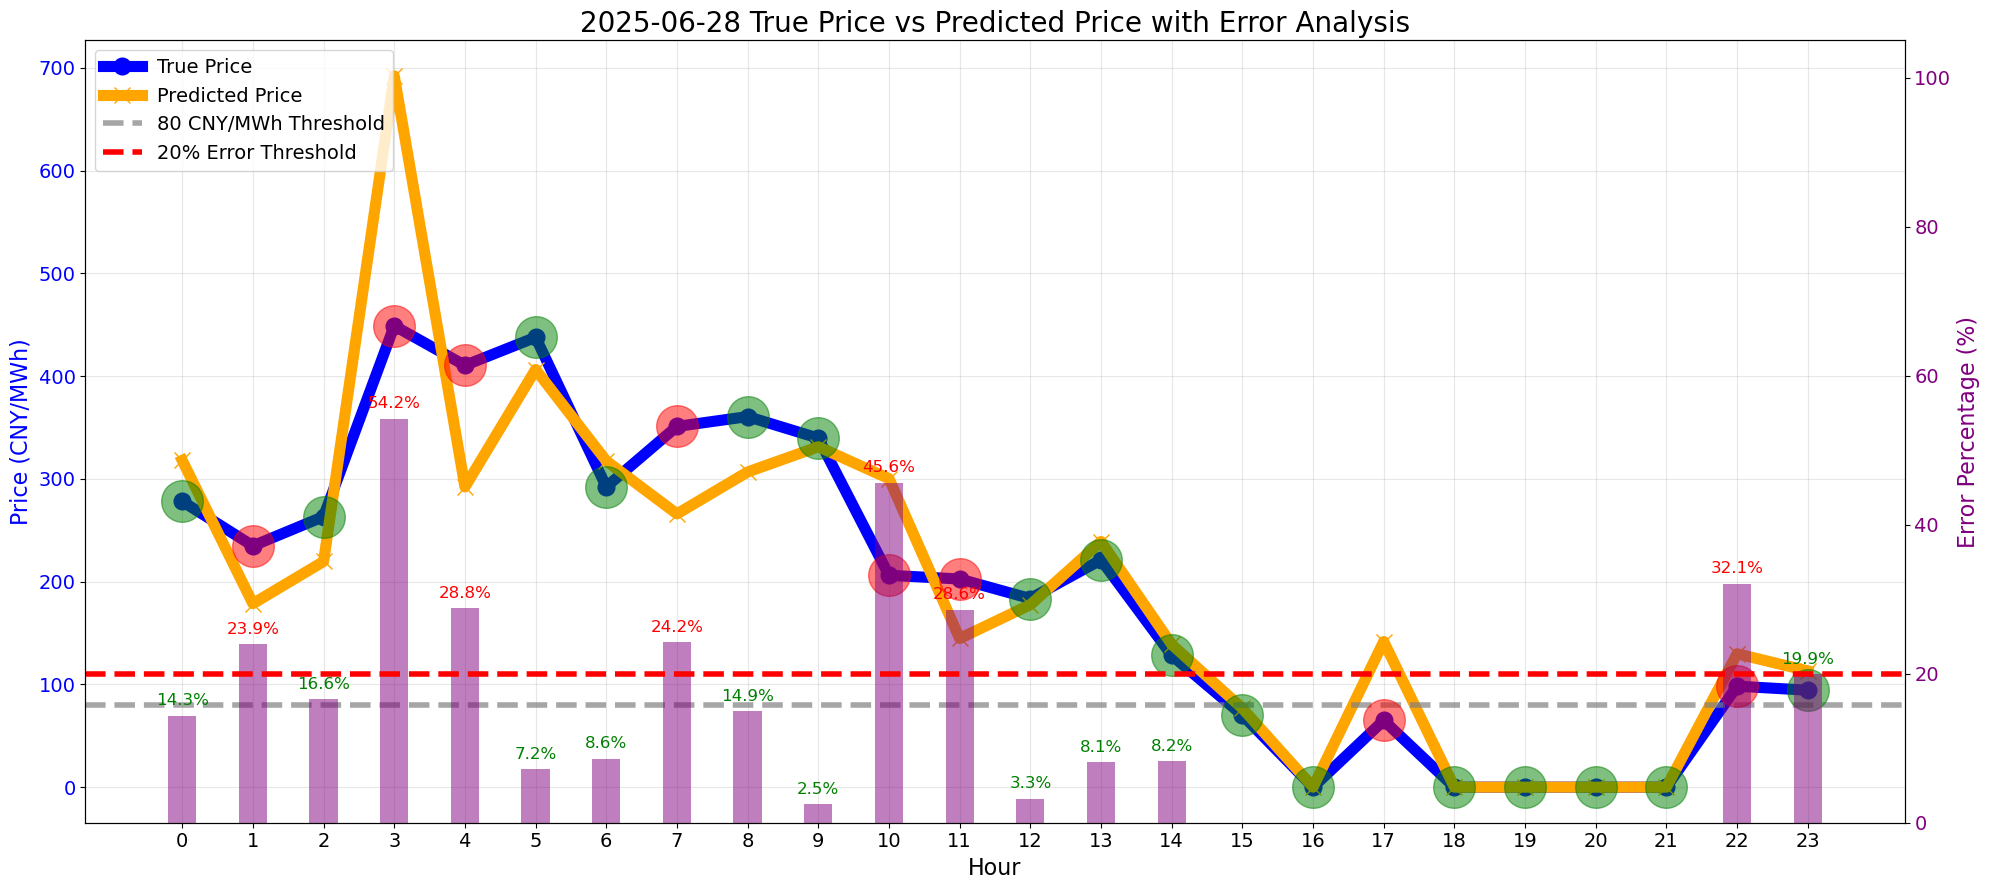

In [7]:
# target_date_str = "2025-04-01"
# target_date_str = "2025-04-14"
# target_date_str = "2025-06-15"
target_date_str = "2025-06-28"
analyze_and_visualize_day_predictions(all_result, target_date_str)

## 8.时段可视化

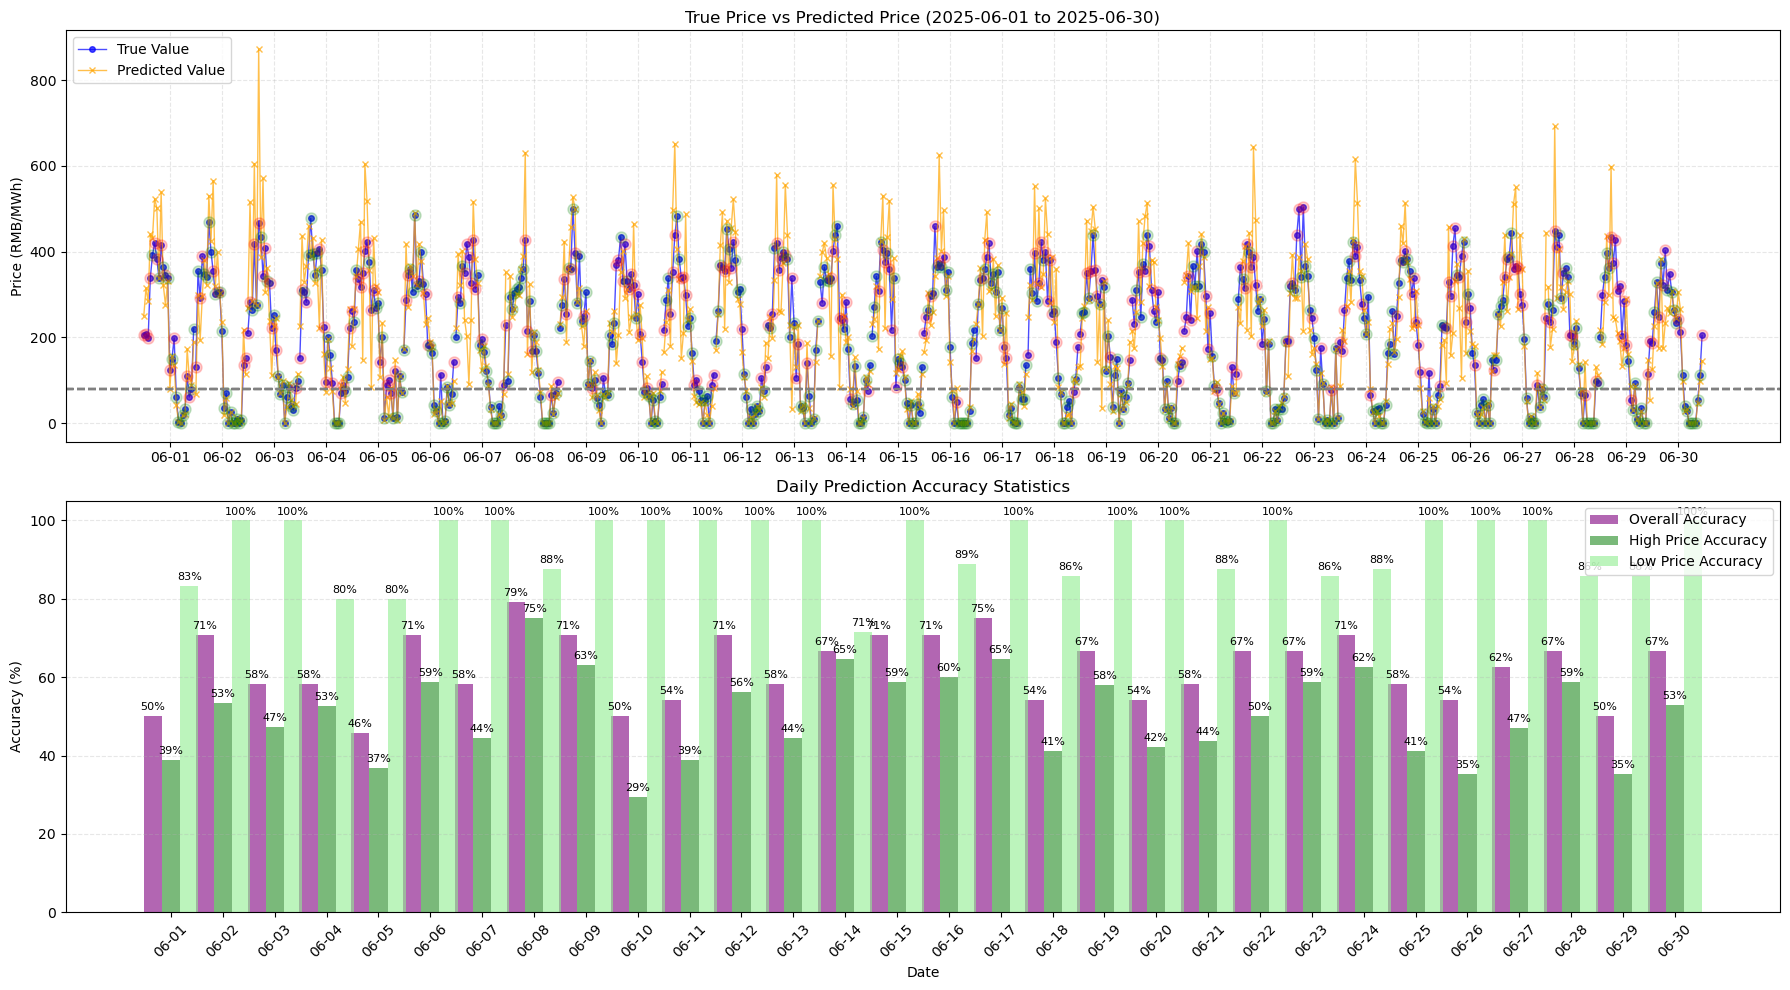

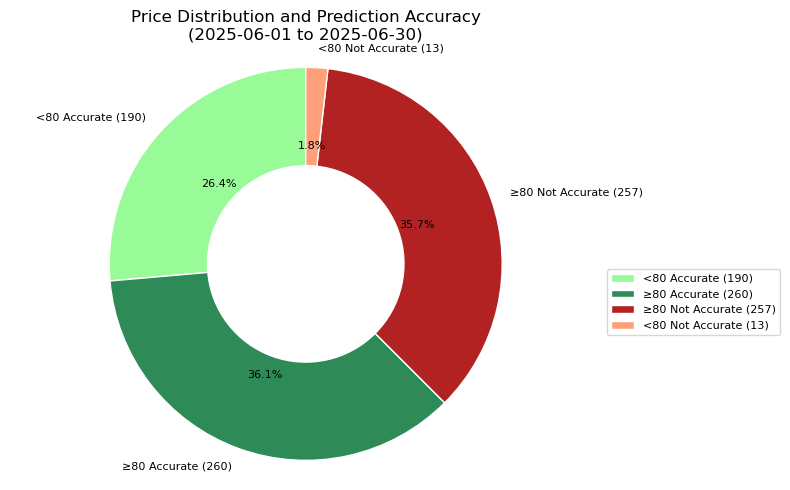

In [8]:
# === 9. 绘制测试集折线图 - 使用新的评估标准 ===

def visualize_predictions_by_date_range(test_result, start_date_str=None, end_date_str=None):
    """
    可视化指定日期范围内的预测结果，包括价格走势和达标率统计
    
    参数:
    test_result: DataFrame, 包含测试结果数据，需要包含date, hour, true, pred, meets_standard, error_pct列
    start_date_str: str, 开始日期，格式为'YYYY-MM-DD'，如果为None则使用测试集的最早日期
    end_date_str: str, 结束日期，格式为'YYYY-MM-DD'，如果为None则使用测试集的最晚日期
    
    返回:
    无，直接显示图表
    """
    # 将日期列转换为datetime类型
    test_result['date'] = pd.to_datetime(test_result['date'])
    
    # 如果未指定日期范围，则使用测试集的全部日期范围
    if start_date_str is None:
        start_date = test_result['date'].min()
    else:
        start_date = pd.to_datetime(start_date_str)
        
    if end_date_str is None:
        end_date = test_result['date'].max()
    else:
        end_date = pd.to_datetime(end_date_str)

    # 筛选指定日期范围内的数据
    filtered_data = test_result[(test_result['date'] >= start_date) & (test_result['date'] <= end_date)]
    
    # 检查是否有数据
    if len(filtered_data) == 0:
        print(f"No data found in the specified date range {start_date.date()} to {end_date.date()}")
        return

    # 按日期分组
    daily_results = []
    for date, group in filtered_data.groupby('date'):
        daily_results.append({
            'date': date,
            'hours': group['hour'].tolist(),
            'true': group['true'].tolist(),
            'pred': group['pred'].tolist(),
            'meets_standard': group['meets_standard'].tolist(),
            'error_pct': group['error_pct'].tolist()
        })

    # 计算每天的达标率
    for day in daily_results:
        valid_points = [i for i, t in enumerate(day['true']) if not np.isnan(t)]
        if valid_points:
            day['standard_met_rate'] = sum(day['meets_standard'][i] for i in valid_points) / len(valid_points) * 100
        else:
            day['standard_met_rate'] = np.nan

    # 绘制多日折线图
    plt.figure(figsize=(18, 10))

    # 创建两个子图
    ax1 = plt.subplot(2, 1, 1)

    # 为每一天创建连续的x轴坐标
    x_ticks = []
    x_labels = []
    x_pos = 0

    for day in daily_results:
        hours_in_day = len(day['hours'])
        
        # 绘制实际值和预测值
        plt.plot(range(x_pos, x_pos + hours_in_day), day['true'], 
                marker='o', markersize=4, label='True Value' if x_pos == 0 else "", 
                color='blue', alpha=0.7, linewidth=1)
        plt.plot(range(x_pos, x_pos + hours_in_day), day['pred'], 
                marker='x', markersize=4, label='Predicted Value' if x_pos == 0 else "", 
                color='orange', alpha=0.7, linewidth=1)
        
        # 添加80元/MWh阈值线
        plt.axhline(y=80, color='gray', linestyle='--', alpha=0.3)
        
        # 标记预测达标与未达标的点
        for i in range(hours_in_day):
            if not np.isnan(day['true'][i]):
                x_coord = x_pos + i
                y_coord = day['true'][i]
                if day['meets_standard'][i]:
                    plt.plot(x_coord, y_coord, 'go', markersize=8, alpha=0.2)  # 绿色圈表示达标
                else:
                    plt.plot(x_coord, y_coord, 'ro', markersize=8, alpha=0.2)  # 红色圈表示未达标
        
        # 添加日期标签
        x_ticks.append(x_pos + hours_in_day // 2)  # 在每天中间位置标记日期
        x_labels.append(pd.to_datetime(str(day['date'])).strftime('%m-%d'))
        
        x_pos += hours_in_day

    plt.ylabel('Price (RMB/MWh)')
    plt.title(f'True Price vs Predicted Price ({start_date.date()} to {end_date.date()})')
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.3)

    # 设置x轴标签
    plt.xticks(x_ticks, x_labels)

    # 在第二个子图中显示每日达标率
    ax2 = plt.subplot(2, 1, 2)
    daily_std_met_rates = [day['standard_met_rate'] for day in daily_results]
    daily_dates = [pd.to_datetime(str(day['date'])).strftime('%m-%d') for day in daily_results]

    # 计算高电价和低电价的达标率
    high_price_std_met_rates = []
    low_price_std_met_rates = []
    high_price_counts = []
    low_price_counts = []

    for day in daily_results:
        high_price_indices = [i for i, t in enumerate(day['true']) if not np.isnan(t) and t >= 80]
        low_price_indices = [i for i, t in enumerate(day['true']) if not np.isnan(t) and t < 80]
        
        high_price_std_met = sum(day['meets_standard'][i] for i in high_price_indices) / len(high_price_indices) * 100 if high_price_indices else np.nan
        low_price_std_met = sum(day['meets_standard'][i] for i in low_price_indices) / len(low_price_indices) * 100 if low_price_indices else np.nan
        
        high_price_std_met_rates.append(high_price_std_met)
        low_price_std_met_rates.append(low_price_std_met)
        high_price_counts.append(len(high_price_indices))
        low_price_counts.append(len(low_price_indices))

    # 绘制每日达标率柱状图
    bar_width = 0.35
    x = np.arange(len(daily_dates))

    # 总体达标率
    bars1 = plt.bar(x, daily_std_met_rates, bar_width, label='Overall Accuracy', color='purple', alpha=0.6)

    # 高电价达标率
    bars2 = plt.bar(x + bar_width, high_price_std_met_rates, bar_width, label='High Price Accuracy', color='forestgreen', alpha=0.6)

    # 低电价达标率
    bars3 = plt.bar(x + 2*bar_width, low_price_std_met_rates, bar_width, label='Low Price Accuracy', color='lightgreen', alpha=0.6)

    # 添加数值标签
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            if not np.isnan(height):
                plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                        f'{height:.0f}%', ha='center', va='bottom', fontsize=8)

    plt.xlabel('Date')
    plt.ylabel('Accuracy (%)')
    plt.title('Daily Prediction Accuracy Statistics')
    plt.xticks(x + bar_width, daily_dates, rotation=45)
    plt.ylim(0, 105)  # 设置y轴范围，留出空间显示标签
    plt.grid(True, axis='y', linestyle='--', alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()


def visualize_price_distribution_and_accuracy(test_result, start_date_str=None, end_date_str=None):
    """
    可视化指定日期范围内测试集中电价分布及预测达标状态
    
    参数:
    test_result: DataFrame, 包含测试结果数据，需要包含date, true, pred, meets_standard列
    start_date_str: str, 开始日期，格式为'YYYY-MM-DD'，如果为None则使用测试集的最早日期
    end_date_str: str, 结束日期，格式为'YYYY-MM-DD'，如果为None则使用测试集的最晚日期
    
    返回:
    无，直接显示图表
    """
    # 将日期列转换为datetime类型
    test_result['date'] = pd.to_datetime(test_result['date'])
    
    # 如果未指定日期范围，则使用测试集的全部日期范围
    if start_date_str is None:
        start_date = test_result['date'].min()
    else:
        start_date = pd.to_datetime(start_date_str)
        
    if end_date_str is None:
        end_date = test_result['date'].max()
    else:
        end_date = pd.to_datetime(end_date_str)

    # 筛选指定日期范围内的数据
    filtered_data = test_result[(test_result['date'] >= start_date) & (test_result['date'] <= end_date)]
    
    # 检查是否有数据
    if len(filtered_data) == 0:
        print(f"No data found in the specified date range {start_date.date()} to {end_date.date()}")
        return
    
    # 计算高电价和低电价的比例及达标情况
    high_price_std_met_count = 0
    high_price_total = 0
    low_price_std_met_count = 0
    low_price_total = 0

    for _, row in filtered_data.iterrows():
        true_val = row['true']
        if not np.isnan(true_val):
            if true_val >= 80:
                high_price_total += 1
                if row['meets_standard']:
                    high_price_std_met_count += 1
            else:
                low_price_total += 1
                if row['meets_standard']:
                    low_price_std_met_count += 1

    # 计算达标和未达标的数量
    high_price_not_met_count = high_price_total - high_price_std_met_count
    low_price_not_met_count = low_price_total - low_price_std_met_count

    # 创建饼图
    plt.figure(figsize=(8, 5))

    # 饼图数据：每个类别中达标和未达标的数量
    sizes = [low_price_std_met_count, high_price_std_met_count,
             high_price_not_met_count, low_price_not_met_count]
    labels = [f'<80 Accurate ({low_price_std_met_count})',
              f'≥80 Accurate ({high_price_std_met_count})',
              f'≥80 Not Accurate ({high_price_not_met_count})',
              f'<80 Not Accurate ({low_price_not_met_count})']
    colors = ['#98FB98', '#2E8B57','#B22222', '#FFA07A']

    # 绘制饼图
    plt.pie(sizes, 
            labels=labels, 
            colors=colors,
            autopct='%1.1f%%',
            startangle=90,
            textprops={'fontsize': 8},
            wedgeprops=dict(width=0.5, edgecolor='w'))

    # 添加中心圆形，使其成为甜甜圈图
    centre_circle = plt.Circle((0,0), 0.5, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    plt.title(f'Price Distribution and Prediction Accuracy\n({start_date.date()} to {end_date.date()})', fontsize=12)
    plt.axis('equal')

    # 添加图例
    plt.legend(loc='best', bbox_to_anchor=(1, 0.5), fontsize=8)
    plt.tight_layout()
    plt.show()



# 调用函数进行可视化 - 默认展示2025年6月的数据
visualize_predictions_by_date_range(all_result, '2025-06-01', '2025-06-30')
visualize_price_distribution_and_accuracy(all_result, '2025-06-01', '2025-06-30')


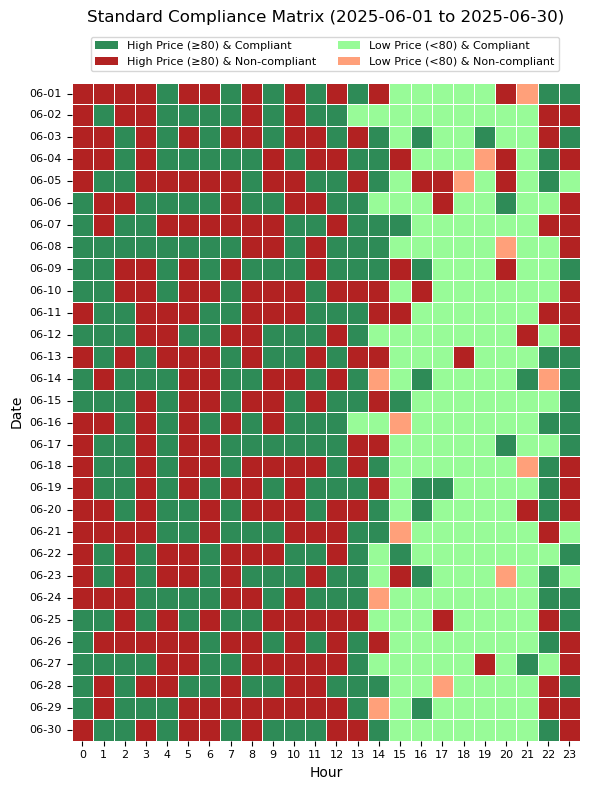

In [9]:
# 定义函数：绘制达标矩阵图
def plot_standard_compliance_matrix(test_result, start_date, end_date):
    """
    绘制达标矩阵图，横轴为小时，纵轴为日期
    
    参数:
    test_result: DataFrame, 包含预测结果
    start_date: str, 开始日期，格式为'YYYY-MM-DD'
    end_date: str, 结束日期，格式为'YYYY-MM-DD'
    """
    # 导入必要的库
    from matplotlib.colors import ListedColormap
    
    # 过滤日期范围内的数据
    filtered_data = test_result[(test_result['date'] >= start_date) & (test_result['date'] <= end_date)].copy()
    
    # 确保日期列是日期类型
    filtered_data['date'] = pd.to_datetime(filtered_data['date'])
    
    # 添加价格区间标记
    filtered_data['price_category'] = filtered_data['true'].apply(lambda x: 'high' if x >= 80 else 'low')
    
    # 创建数据透视表：日期为行，小时为列，值为是否达标和价格区间
    pivot_data = filtered_data.pivot_table(
        index='date', 
        columns='hour', 
        values=['meets_standard', 'price_category'],
        aggfunc=lambda x: x.iloc[0] if len(x) > 0 else None
    )
    
    # 创建一个新的数组来存储颜色映射值
    color_values = np.zeros((len(pivot_data), 24))
    
    # 设置颜色映射：
    # 0: 高价格且达标 - 深绿色
    # 1: 高价格但不达标 - 深红色
    # 2: 低价格且达标 - 浅绿色
    # 3: 低价格但不达标 - 浅红色
    for i, date in enumerate(pivot_data.index):
        for hour in range(24):
            try:
                is_compliant = pivot_data[('meets_standard', hour)].loc[date]
                is_high_price = pivot_data[('price_category', hour)].loc[date] == 'high'
                
                if is_high_price:
                    color_values[i, hour] = 0 if is_compliant else 1
                else:
                    color_values[i, hour] = 2 if is_compliant else 3
            except:
                # 处理可能的缺失值
                color_values[i, hour] = np.nan
    
    # 设置图形大小
    plt.figure(figsize=(6, 8))
    
    # 自定义颜色映射 - 使用更美观的配色
    custom_cmap = ListedColormap(['#2E8B57', '#B22222', '#98FB98', '#FFA07A'])
    
    # 创建热力图
    ax = sns.heatmap(
        color_values,
        cmap=custom_cmap,
        cbar=False,
        linewidths=0.5,
        linecolor='white'
    )
    
    # 设置标题和标签
    plt.title(f'Standard Compliance Matrix ({start_date} to {end_date})\n\n\n', fontsize=12)
    
    # 添加图例
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2E8B57', label='High Price (≥80) & Compliant'),
        Patch(facecolor='#B22222', label='High Price (≥80) & Non-compliant'),
        Patch(facecolor='#98FB98', label='Low Price (<80) & Compliant'),
        Patch(facecolor='#FFA07A', label='Low Price (<80) & Non-compliant')
    ]
    plt.figlegend(handles=legend_elements, loc='upper center', ncol=2, fontsize=8, bbox_to_anchor=(0.55, 0.955))
    
    plt.xlabel('Hour', fontsize=10)
    plt.ylabel('Date', fontsize=10)
    
    # 调整y轴日期标签格式
    date_labels = [d.strftime('%m-%d') for d in pivot_data.index]
    ax.set_yticklabels(date_labels, rotation=0, fontsize=8)
    ax.set_xticklabels(range(24), fontsize=8)
    
    plt.tight_layout()
    plt.show()

# 调用函数绘制达标矩阵图 - 默认展示2025年6月的数据
plot_standard_compliance_matrix(all_result, '2025-06-01', '2025-06-30')

## 9.达标分布可视化

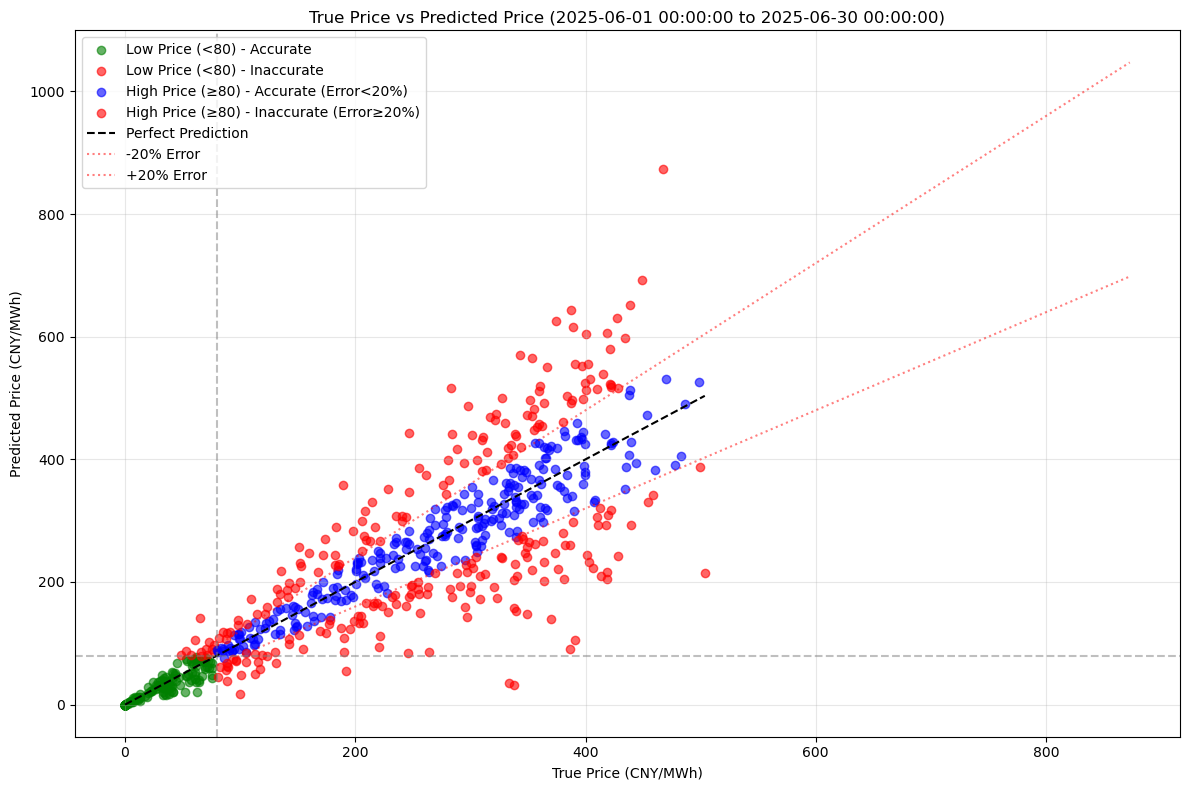

In [10]:
# MARK 暂时不用
# 定义函数：预测误差统计和分析
def analyze_prediction_accuracy(test_result, start_date, end_date):
    """
    根据新的评估标准分析预测准确性
    
    参数:
    test_result: DataFrame, 包含预测结果
    start_date: str, 开始日期，格式为'YYYY-MM-DD'
    end_date: str, 结束日期，格式为'YYYY-MM-DD'
    
    返回:
    dict: 包含各种统计结果的字典
    """
    # 过滤日期范围内的数据
    filtered_data = test_result[(test_result['date'] >= start_date) & (test_result['date'] <= end_date)]
    
    # 从测试结果中提取数据
    all_y_test_array = np.array(filtered_data['true'])
    all_y_pred_array = np.array(filtered_data['pred'])
    all_y_hour_array = np.array(filtered_data['hour'])
    
    # 创建DataFrame便于分析
    results_df = pd.DataFrame({
        'hour': all_y_hour_array,
        'true_price': all_y_test_array,
        'pred_price': all_y_pred_array
    })
    
    # 分类电价
    results_df['price_category'] = np.where(results_df['true_price'] >= 80, 'High Price (≥80)', 'Low Price (<80)')
    results_df['pred_category'] = np.where(results_df['pred_price'] >= 80, 'High Price (≥80)', 'Low Price (<80)')
    
    # 计算高电价区间的预测误差百分比
    results_df['error_pct'] = np.where(
        results_df['true_price'] >= 80,
        abs(results_df['true_price'] - results_df['pred_price']) / results_df['true_price'] * 100,
        np.nan
    )
    
    # 评估预测准确性
    # 高电价区间：误差小于20%为准确
    # 低电价区间：预测为低电价即为准确
    results_df['is_accurate'] = np.where(
        results_df['true_price'] >= 80,
        results_df['error_pct'] < 20,
        results_df['pred_price'] < 80
    )
    
    # 按小时统计准确率
    hourly_accuracy = results_df.groupby('hour')['is_accurate'].mean() * 100
    
    # 按电价类别统计准确率
    category_accuracy = results_df.groupby('price_category')['is_accurate'].mean() * 100
    
    # 统计总体准确率
    overall_accuracy = results_df['is_accurate'].mean() * 100
    
    # 高电价区间的误差分布
    high_price_errors = results_df[results_df['true_price'] >= 80]['error_pct']
    high_price_error_stats = {
        'mean': high_price_errors.mean(),
        'median': high_price_errors.median(),
        'std': high_price_errors.std(),
        'min': high_price_errors.min(),
        'max': high_price_errors.max(),
        'count': high_price_errors.count(),
        'below_20pct': (high_price_errors < 20).mean() * 100
    }
    
    # 低电价区间的分类准确率
    low_price_accuracy = results_df[results_df['true_price'] < 80]['is_accurate'].mean() * 100
    
    # 混淆矩阵
    confusion = pd.crosstab(
        results_df['price_category'], 
        results_df['pred_category'],
        normalize='index'
    ) * 100
    
    return {
        'results_df': results_df,
        'overall_accuracy': overall_accuracy,
        'category_accuracy': category_accuracy,
        'high_price_error_stats': high_price_error_stats,
        'low_price_accuracy': low_price_accuracy,
        'confusion': confusion,
        'filtered_data': filtered_data
    }

# 函数：绘制真实价格与预测价格的散点图
def plot_price_scatter(test_result, start_date, end_date):
    """
    绘制真实价格与预测价格的散点图，按电价类别和准确性着色
    
    参数:
    test_result: DataFrame, 包含预测结果
    start_date: str, 开始日期，格式为'YYYY-MM-DD'
    end_date: str, 结束日期，格式为'YYYY-MM-DD'
    """
    # 获取分析结果
    analysis_results = analyze_prediction_accuracy(test_result, start_date, end_date)
    results_df = analysis_results['results_df']
    
    plt.figure(figsize=(12, 8))
    
    # 绘制低电价数据点
    low_price_mask = results_df['true_price'] < 80
    low_price_accurate = low_price_mask & results_df['is_accurate']
    plt.scatter(
        results_df.loc[low_price_accurate, 'true_price'],
        results_df.loc[low_price_accurate, 'pred_price'],
        alpha=0.6, label='Low Price (<80) - Accurate', color='green'
    )
    low_price_inaccurate = low_price_mask & ~results_df['is_accurate']
    plt.scatter(
        results_df.loc[low_price_inaccurate, 'true_price'],
        results_df.loc[low_price_inaccurate, 'pred_price'],
        alpha=0.6, label='Low Price (<80) - Inaccurate', color='red'
    )
    
    # 绘制高电价数据点，区分准确和不准确
    high_price_mask = results_df['true_price'] >= 80
    high_price_accurate = high_price_mask & results_df['is_accurate']
    high_price_inaccurate = high_price_mask & ~results_df['is_accurate']
    
    plt.scatter(
        results_df.loc[high_price_accurate, 'true_price'],
        results_df.loc[high_price_accurate, 'pred_price'],
        alpha=0.6, label='High Price (≥80) - Accurate (Error<20%)', color='blue'
    )
    
    plt.scatter(
        results_df.loc[high_price_inaccurate, 'true_price'],
        results_df.loc[high_price_inaccurate, 'pred_price'],
        alpha=0.6, label='High Price (≥80) - Inaccurate (Error≥20%)', color='red'
    )
    
    # 添加参考线
    plt.plot([0, results_df['true_price'].max()], [0, results_df['true_price'].max()], 
             'k--', label='Perfect Prediction')
    plt.axhline(y=80, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(x=80, color='gray', linestyle='--', alpha=0.5)
    
    # 添加20%误差范围参考线
    max_val = max(results_df['true_price'].max(), results_df['pred_price'].max())
    x = np.linspace(80, max_val, 100)
    plt.plot(x, x * 0.8, 'r:', alpha=0.5, label='-20% Error')
    plt.plot(x, x * 1.2, 'r:', alpha=0.5, label='+20% Error')
    
    plt.xlabel('True Price (CNY/MWh)')
    plt.ylabel('Predicted Price (CNY/MWh)')
    plt.title(f'True Price vs Predicted Price ({start_date} to {end_date})')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 函数：绘制按年月和小时的准确率热力图
def plot_accuracy_heatmap_by_year_month(test_result, start_date, end_date):
    """
    绘制按年月和小时的预测准确率热力图
    
    参数:
    test_result: DataFrame, 包含预测结果
    start_date: str, 开始日期，格式为'YYYY-MM-DD'
    end_date: str, 结束日期，格式为'YYYY-MM-DD'
    """
    # 获取分析结果
    analysis_results = analyze_prediction_accuracy(test_result, start_date, end_date)
    filtered_data = analysis_results['filtered_data']
    
    # 创建一个新的DataFrame，按年月和小时统计达标率
    monthly_results_df = pd.DataFrame({
        'year_month': pd.to_datetime(filtered_data['date']).dt.strftime('%Y-%m'),
        'hour': filtered_data['hour'],
        'true_price': filtered_data['true'],
        'pred_price': filtered_data['pred'],
        'meets_standard': np.where(
            filtered_data['true'] >= 80,
            abs(filtered_data['true'] - filtered_data['pred']) / filtered_data['true'] * 100 < 20,
            filtered_data['pred'] < 80
        )
    })
    
    # 计算每个(年月,小时)组合的达标率
    heatmap_data = monthly_results_df.groupby(['year_month', 'hour'])['meets_standard'].mean().unstack() * 100
    
    # 对年月进行排序
    heatmap_data = heatmap_data.sort_index()
    
    # 绘制热力图
    plt.figure(figsize=(18, 10))
    sns.heatmap(heatmap_data, cmap='RdYlGn', vmin=0, vmax=100, annot=True, fmt='.0f', linewidths=.5, cbar_kws={'label': 'Standard Met Rate (%)'})
    plt.title(f'Prediction Standard Met Rate by Year-Month and Hour ({start_date} to {end_date})')
    plt.xlabel('Hour')
    plt.ylabel('Year-Month')
    
    # 调整刻度标签
    plt.xticks(np.arange(24) + 0.5, range(24))
    plt.yticks(np.arange(len(heatmap_data.index)) + 0.5, heatmap_data.index, rotation=0)
    
    plt.tight_layout()
    plt.show()

# 函数：绘制按月份和小时的平均准确率热力图
def plot_accuracy_heatmap_by_month(test_result, start_date, end_date):
    """
    绘制按月份和小时的平均预测准确率热力图（合并所有年份）
    
    参数:
    test_result: DataFrame, 包含预测结果
    start_date: str, 开始日期，格式为'YYYY-MM-DD'
    end_date: str, 结束日期，格式为'YYYY-MM-DD'
    """
    # 获取分析结果
    analysis_results = analyze_prediction_accuracy(test_result, start_date, end_date)
    filtered_data = analysis_results['filtered_data']
    
    # 创建一个新的DataFrame，按月份和小时统计达标率
    monthly_results_df = pd.DataFrame({
        'month': pd.to_datetime(filtered_data['date']).dt.month,
        'hour': filtered_data['hour'],
        'true_price': filtered_data['true'],
        'pred_price': filtered_data['pred'],
        'meets_standard': np.where(
            filtered_data['true'] >= 80,
            abs(filtered_data['true'] - filtered_data['pred']) / filtered_data['true'] * 100 < 20,
            filtered_data['pred'] < 80
        )
    })
    
    # 计算每个(月份,小时)组合的达标率
    monthly_heatmap_data = monthly_results_df.groupby(['month', 'hour'])['meets_standard'].mean().unstack() * 100
    
    # 对月份进行排序
    monthly_heatmap_data = monthly_heatmap_data.sort_index()
    
    # 绘制热力图
    plt.figure(figsize=(18, 8))
    sns.heatmap(monthly_heatmap_data, cmap='RdYlGn', vmin=0, vmax=100, annot=True, fmt='.0f', linewidths=.5, cbar_kws={'label': 'Standard Met Rate (%)'})
    plt.title(f'Average Prediction Standard Met Rate by Month and Hour ({start_date} to {end_date})')
    plt.xlabel('Hour')
    plt.ylabel('Month')
    
    # 调整刻度标签
    plt.xticks(np.arange(24) + 0.5, range(24))
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    plt.yticks(np.arange(len(monthly_heatmap_data.index)) + 0.5, [month_names[i-1] for i in monthly_heatmap_data.index], rotation=0)
    
    plt.tight_layout()
    plt.show()

# 示例调用 - 默认展示2025年6月的数据

# 调用函数进行分析和可视化
plot_price_scatter(all_result, test_begin_date, test_end_date)

# plot_accuracy_heatmap_by_year_month(test_result, '2024-06-01', '2025-06-30')
# plot_accuracy_heatmap_by_month(test_result, '2024-06-01', '2025-06-30')
